# 得点時刻の分布

得点が試合のどの時間帯に多いかを見る。
全リーグ・全シーズンの得点時刻でヒストグラムを描き、カーネル密度推定（KDE）の曲線を重ねる。

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# グラフの日本語が文字化けしないようにする
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False


/Users/fujitaharukanin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. データの読み込み

`statsbomb_data` にある全リーグ・全シーズンの `*_goals_and_red_cards.csv` を読み込んで、1つの表にまとめる。

In [2]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461


## 2. 得点時刻を取り出す

データには得点の行と退場の行が混ざっているので、得点の行だけを取り出す。
得点時刻（分）は `minute + second / 60` で計算する。

In [3]:
goal_rows = df_all[df_all["red_card"].isna() & df_all["home_away"].notna()].copy()
goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0

scoring_times = goal_rows["time_min"].dropna().to_numpy()
print(f"得点イベント数: {len(scoring_times)}")
print(f"時刻の範囲: {scoring_times.min():.2f}分 〜 {scoring_times.max():.2f}分")


得点イベント数: 6964
時刻の範囲: 0.03分 〜 128.97分


## 3. ヒストグラムとKDEを描く

ヒストグラムとKDEを重ねて描く関数を作る。ビン幅を変えて何回か使う。

In [4]:
BAR_COLOR = "#6699CC"
KDE_COLOR = "#E69F00"

os.makedirs("./figures", exist_ok=True)


def plot_scoring_time_histogram(values, bin_width, title, out_path,
                                 xlabel="得点時刻（試合開始からの経過時間, 分）",
                                 x_min=0.0, x_max=None):
    x_max = np.ceil(values.max() / bin_width) * bin_width if x_max is None else x_max
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)

    fig, ax = plt.subplots(figsize=(10, 6))

    # ヒストグラム（密度表示）
    ax.hist(values, bins=bin_edges, density=True, color=BAR_COLOR,
            edgecolor="white", linewidth=0.5, alpha=0.85, label=f"ヒストグラム（{bin_width:g}刻み）")

    # カーネル密度推定
    kde = gaussian_kde(values)
    x_grid = np.linspace(bin_edges[0], bin_edges[-1], 500)
    ax.plot(x_grid, kde(x_grid), color=KDE_COLOR, linewidth=2.2, label="カーネル密度推定 (KDE)")

    ax.set_xlim(bin_edges[0], bin_edges[-1])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("密度")
    ax.set_title(f"{title}\n(n={len(values)})")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")
    fig.tight_layout()

    fig.savefig(out_path, dpi=150)
    print(f"保存しました: {out_path}")
    plt.show()

    return fig, ax


### 3-1. 1分刻み

保存しました: ./figures/scoring_time_histogram_1min_kde.png


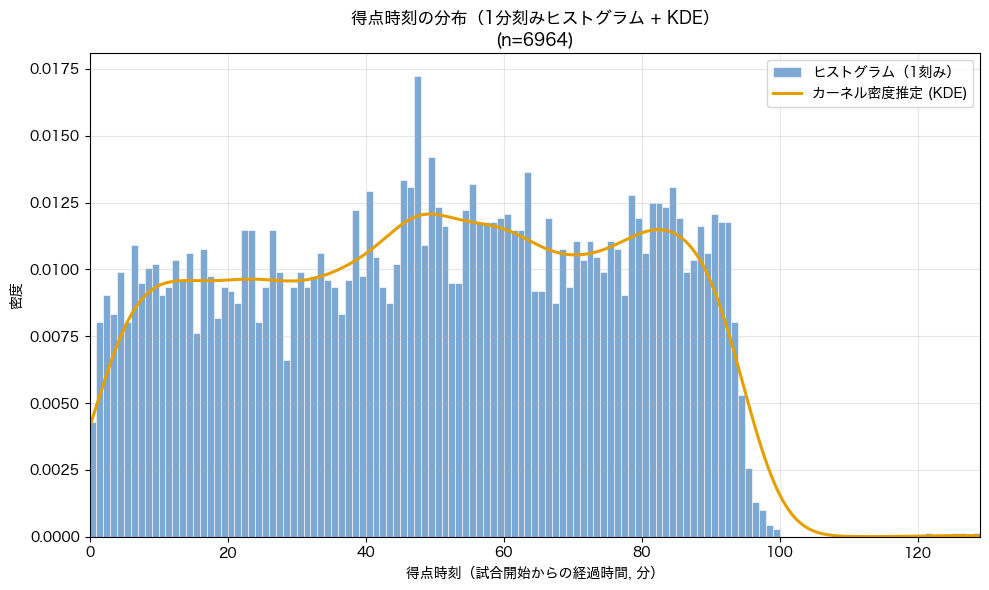

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': '得点時刻の分布（1分刻みヒストグラム + KDE）\n(n=6964)'}, xlabel='得点時刻（試合開始からの経過時間, 分）', ylabel='密度'>)

In [5]:
plot_scoring_time_histogram(
    scoring_times,
    bin_width=1,
    title="得点時刻の分布（1分刻みヒストグラム + KDE）",
    out_path="./figures/scoring_time_histogram_1min_kde.png",
)


### 3-2. 5分刻み

保存しました: ./figures/scoring_time_histogram_5min_kde.png


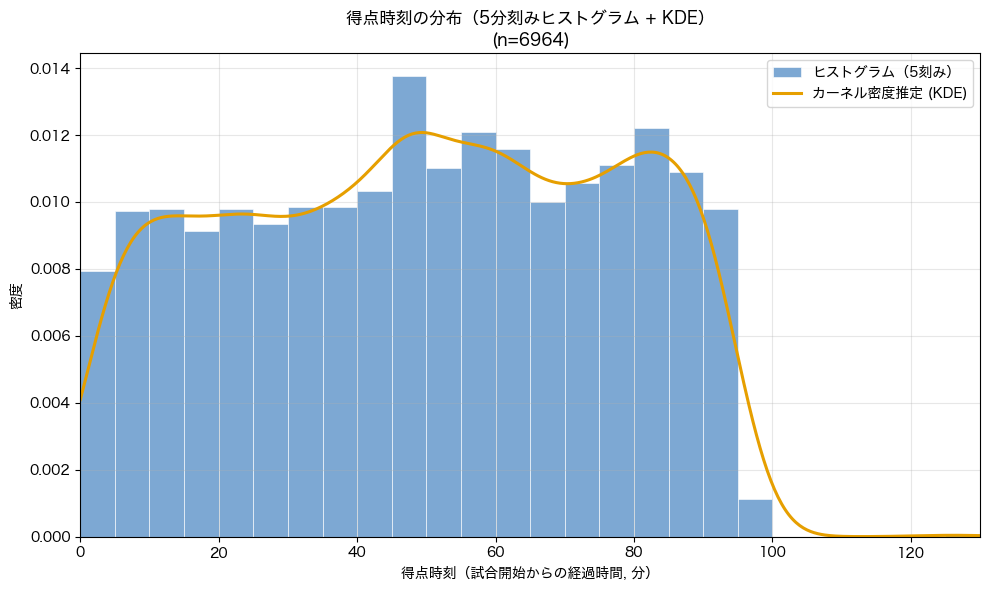

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': '得点時刻の分布（5分刻みヒストグラム + KDE）\n(n=6964)'}, xlabel='得点時刻（試合開始からの経過時間, 分）', ylabel='密度'>)

In [6]:
plot_scoring_time_histogram(
    scoring_times,
    bin_width=5,
    title="得点時刻の分布（5分刻みヒストグラム + KDE）",
    out_path="./figures/scoring_time_histogram_5min_kde.png",
)


## 4. `dr_time` で描く

`dr_time` は、試合開始を0、試合終了を1にした時間。アディショナルタイムの長さは試合ごとに違うので、こちらでも見ておく。
ビン幅は0.05（20分割で、だいたい5分刻み）にする。

In [7]:
dr_times = goal_rows["dr_time"].dropna().to_numpy()
print(f"dr_time が取得できた得点イベント数: {len(dr_times)}")
print(f"dr_time の範囲: {dr_times.min():.4f} 〜 {dr_times.max():.4f}")

DR_BIN_WIDTH = 0.05  # 20分割（だいたい5分刻み）


dr_time が取得できた得点イベント数: 6964
dr_time の範囲: 0.0004 〜 1.0000


保存しました: ./figures/scoring_time_histogram_drtime_kde.png


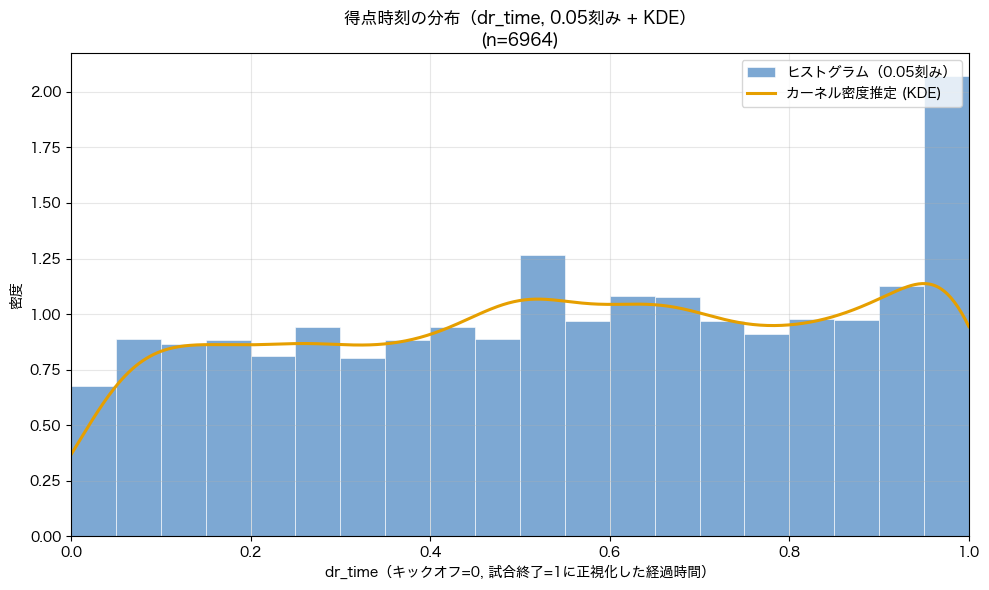

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': '得点時刻の分布（dr_time, 0.05刻み + KDE）\n(n=6964)'}, xlabel='dr_time（キックオフ=0, 試合終了=1に正視化した経過時間）', ylabel='密度'>)

In [8]:
plot_scoring_time_histogram(
    dr_times,
    bin_width=DR_BIN_WIDTH,
    title=f"得点時刻の分布（dr_time, {DR_BIN_WIDTH:g}刻み + KDE）",
    out_path="./figures/scoring_time_histogram_drtime_kde.png",
    xlabel="dr_time（キックオフ=0, 試合終了=1に正規化した経過時間）",
    x_min=0.0,
    x_max=1.0,
)
